# **XGBoost GridSearchCV**

Model ini merupakan model yang digunakan oleh author paper, sehingga model ini akan dijadikan sebagai baseline dari project ini.

In [39]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load dan Split Data**

Author hanya menggunakan 7 feature, yakni 'EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', dan 'MACD_signal'. Lalu, targetnya adalah 'Target_Close'. <br>
Data displit based on 70:15:15 untuk train : val : test <br>
Data tidak displit secara acak, namum split based on time.

In [40]:
processed_file = os.path.join("..", "..", "data", "processed", "ihsg_processed_1.csv")
if not os.path.exists(processed_file):
    raise FileNotFoundError(f"File {processed_file} tidak ditemukan. Jalankan Data_Preparation.ipynb dulu!")
    
df = pd.read_csv(processed_file, index_col=0, parse_dates=True)
df = df.sort_index()

feature_cols = ['EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', 'MACD_signal']
target_col = 'Target_Close'

X = df[feature_cols]
y = df[target_col]

total_rows = len(df)
train_end = int(total_rows * 0.70)
val_end = train_end + int(total_rows * 0.15)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]
print(f"Data Shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Data Shapes - Train: (2695, 7), Val: (577, 7), Test: (579, 7)


### **Training Model with GridSearchCV**

Author menggunakan GridSearchCV sebagai tool untuk mencari parameter terbaik. GridSearchCV sendiri akan mencoba segala possibility susunan dari parameternya (permutasi), lalu mengambil susunan parameter yang menghasilkan score terbaik. <br>
Parameter yang digunakan author beserta valuenya antara lain:

- 'n_estimators': [100, 200, 300, 400],
- 'learning_rate': [0.001, 0.005, 0.01, 0.05],
- 'max_depth': [8, 10, 12, 15],
- 'gamma': [0.001, 0.005, 0.01, 0.02],
- 'random_state': [42, 43, 44, 45]

Note: Random state tidak memengaruhi kemampuan model. Random_state hanyalah sebuah angka "seed" acak agar hasil kodenya konsisten (tidak berubah-ubah setiap kali di-run). Tapi, agar sesuai dengan parameter author, akan tetap dimasukkan random seed ke dalam GridSearchCV nya. <br>

Setelah selesai running, best parameternya akan disimpan di outputs\metrics\XG_grid_metrics.json dan model pkl nya disimpan di outputs\models\XG_grid_model.pkl

In [41]:
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.001, 0.005, 0.01, 0.05],
    'max_depth': [8, 10, 12, 15],
    'gamma': [0.001, 0.005, 0.01, 0.02],
    'random_state': [42, 43, 44, 45]
}

grid = ParameterGrid(param_grid)
print(f"Total kombinasi parameter yang akan dievaluasi: {len(grid)}")

best_val_mse = float('inf')
best_params = None

start_time = time.time()
for i, params in enumerate(grid):
    model = XGBRegressor(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_mse = mean_squared_error(y_val, val_preds)
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_params = params
execution_time = time.time() - start_time
print(f"Waktu Eksekusi: {execution_time:.2f} detik")
print(f"Parameter Terbaik: {best_params}")

best_model = XGBRegressor(**best_params, n_jobs=-1)
best_model.fit(X_train, y_train)


Total kombinasi parameter yang akan dievaluasi: 1024
Waktu Eksekusi: 437.27 detik
Parameter Terbaik: {'gamma': 0.01, 'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 400, 'random_state': 42}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### **Evaluation and Save**

Evaluasi akan menggunakan 5 metric:
1. MAPE (Mean Absolute Percentage Error): Mengukur seberapa jauh atau akurat sebuah model prediksi dalam memperkirakan suatu nilai, dan hasilnya dinyatakan dalam bentuk persentase.
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

2. MSE (Mean Squared Error): $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

3. RMSE (Root Mean Squared Error): $$RMSE = \sqrt{MSE}$$

4. MAE (Mean Absolute Error): $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

5. Hit Rate: Menghitung seberapa akurat model menebak arah pergerakan pasar.
$$\text{Hit Rate} = \left( \frac{1}{N} \sum_{i=1}^{N} I \left( \text{sgn}(\hat{y}_{i+1} - y_i) = \text{sgn}(y_{i+1} - y_i) \right) \right) \times 100\%$$

Keterangan untuk hit rate:
* $N$ = Jumlah total pengujian langkah pergerakan harga yang valid.
* $I$ = Fungsi indikator (bernilai 1 jika arah tebakan benar, dan 0 jika salah).
* $\text{sgn}$ = Fungsi *sign* (mendeteksi apakah pergerakan harian naik atau turun).
* $\hat{y}_{i+1}$ = Harga prediksi untuk hari esok.
* $y_{i+1}$ = Harga penutupan aktual hari esok.
* $y_i$ = Harga penutupan aktual hari ini.

In [42]:
import json
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [43]:
test_preds = best_model.predict(X_test)

# MAPE
actual = y_test.values
percentage_errors = np.abs((test_preds - actual) / actual) * 100
mape = np.mean(percentage_errors)
print(f"MAPE: {mape:.4f}%")

# MSE
test_mse = mean_squared_error(y_test, test_preds)
print(f"MSE: {test_mse:.4f}")

# RMSE
test_rmse = np.sqrt(test_mse)
print(f"RMSE: {test_rmse:.4f}")

# MAE
mae = mean_absolute_error(actual, test_preds)
print(f"MAE: {mae:.4f}")

# Hit Rate
arah_aktual = np.sign(actual[1:] - actual[:-1])
arah_prediksi = np.sign(test_preds[1:] - actual[:-1])

valid_idx = arah_aktual != 0 
hit_rate = (arah_prediksi[valid_idx] == arah_aktual[valid_idx]).mean() * 100
print(f"Hit Rate: {hit_rate:.4f}%")

# Save metrics dan model
metrics_results = {
    "method": "GridSearchCV",
    "execution_time_seconds": execution_time,
    "best_params": best_params,
    "best_validation_mse": float(best_val_mse),
    "test_mse": float(test_mse),
    "test_rmse": float(test_rmse),
    "test_mae": float(mae),
    "mape": float(mape),
    "hit_rate_percentage": float(hit_rate)
}

with open(os.path.join("..", "..", "outputs", "metrics", "XG_grid_metrics.json"), "w") as f:
    json.dump(metrics_results, f, indent=4)

joblib.dump(best_model, (os.path.join("..", "..", "outputs", "models", "XG_grid_model.pkl")))
print("Model dan metrik berhasil disimpan.")


MAPE: 10.6471%
MSE: 853577.9333
RMSE: 923.8928
MAE: 804.0676
Hit Rate: 46.1938%
Model dan metrik berhasil disimpan.


### **Visualisasi: Actual vs Predicted**

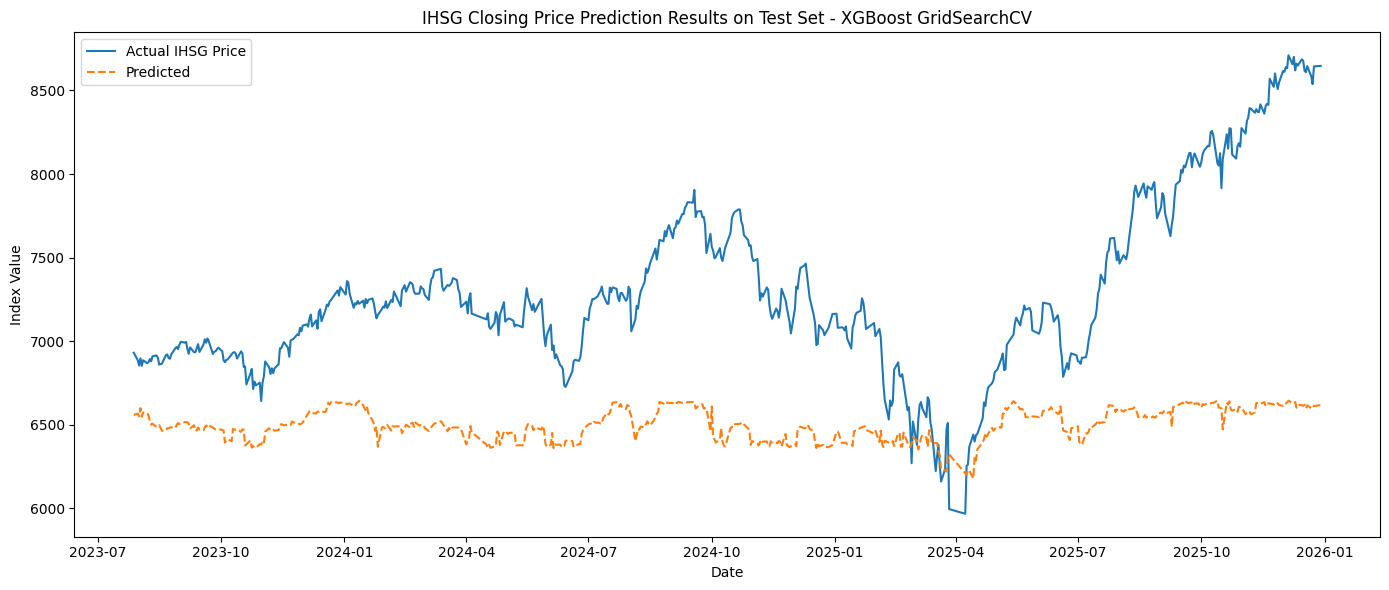

In [44]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual IHSG Price", color='#1f77b4', linewidth=1.5)
plt.plot(y_test.index, test_preds, label="Predicted", color='#ff7f0e', linestyle='--', linewidth=1.5)
plt.title("IHSG Closing Price Prediction Results on Test Set - XGBoost GridSearchCV")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "..", "outputs", "plots", "price_movement_XG_grid.png"), dpi=300)
plt.show()


### **Visualisasi: Feature Importance**

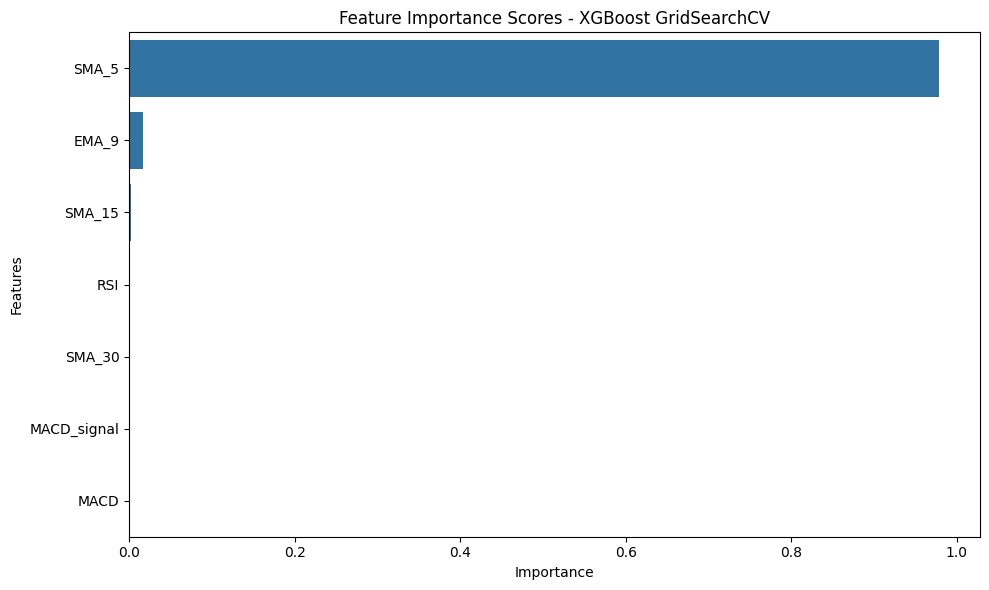

In [45]:
importance_scores = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Features', data=importance_df)
plt.title("Feature Importance Scores - XGBoost GridSearchCV")
plt.tight_layout()
plt.savefig(os.path.join("..", "..", "outputs", "plots", "features_importance_XG_grid.png"), dpi=300)
plt.show()
